# Data Preprocessing — Student Learner Type Prediction






## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)


## 2. Load the Dataset

We load the CSV file into a pandas DataFrame.

In [2]:
df = pd.read_csv('ai_impact_student_performance_dataset_1.csv')
df.head()


,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,ai_generated_content_percentage,ai_prompts_per_week,ai_ethics_score,last_exam_score,assignment_scores_avg,attendance_percentage,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,29,56,5,29,40.9,98.8,4,9,8.1,7.2,1.5,4.6,6,36.8,0,Low
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,14,65,1,60,87.2,89.3,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,82,8,5,98,77.1,50.8,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,74,106,10,67,86.4,52.1,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,83,7,10,40,69.4,40.7,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low


## 3. Understand the Data

Basic checks: shape, column names, data types, and summary statistics.

In [3]:
print("Shape (rows, columns):", df.shape)
print()
print("Column names:")
print(df.columns.tolist())


Shape (rows, columns): (8000, 26)

Column names:
['student_id', 'age', 'gender', 'grade_level', 'study_hours_per_day', 'uses_ai', 'ai_usage_time_minutes', 'ai_tools_used', 'ai_usage_purpose', 'ai_dependency_score', 'ai_generated_content_percentage', 'ai_prompts_per_week', 'ai_ethics_score', 'last_exam_score', 'assignment_scores_avg', 'attendance_percentage', 'concept_understanding_score', 'study_consistency_index', 'improvement_rate', 'sleep_hours', 'social_media_hours', 'tutoring_hours', 'class_participation_score', 'final_score', 'passed', 'performance_category']


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   student_id                       8000 non-null   int64  
 1   age                              8000 non-null   int64  
 2   gender                           8000 non-null   object 
 3   grade_level                      8000 non-null   object 
 4   study_hours_per_day              8000 non-null   float64
 5   uses_ai                          8000 non-null   int64  
 6   ai_usage_time_minutes            8000 non-null   int64  
 7   ai_tools_used                    6638 non-null   object 
 8   ai_usage_purpose                 6654 non-null   object 
 9   ai_dependency_score              8000 non-null   int64  
 10  ai_generated_content_percentage  8000 non-null   int64  
 11  ai_prompts_per_week              8000 non-null   int64  
 12  ai_ethics_score     

In [4]:
df.describe()


,student_id,age,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_dependency_score,ai_generated_content_percentage,ai_prompts_per_week,ai_ethics_score,last_exam_score,assignment_scores_avg,attendance_percentage,concept_understanding_score,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed
count,8000.00000,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,18.96725,3.286938,0.641000,88.989875,5.515125,50.057500,59.359500,5.472375,59.501250,65.108400,69.852112,5.484750,10.127325,6.465025,3.010600,2.523387,5.463375,56.811988,0.889250
std,2309.54541,3.15316,1.582171,0.479737,52.184077,2.883064,29.440109,34.869496,2.872067,23.161888,20.022293,17.234339,2.898546,17.479288,1.435670,1.744974,1.436991,2.881917,13.455724,0.313842
min,1.00000,14.00000,0.500000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,20.000000,30.000000,40.000000,1.000000,-20.000000,4.000000,0.000000,0.000000,1.000000,12.700000,0.000000
25%,2000.75000,16.00000,1.900000,0.000000,43.000000,3.000000,25.000000,29.000000,3.000000,39.750000,47.900000,54.800000,3.000000,-5.000000,5.200000,1.500000,1.300000,3.000000,47.300000,1.000000
50%,4000.50000,19.00000,3.300000,1.000000,89.000000,6.000000,50.000000,59.000000,6.000000,59.000000,65.100000,70.000000,5.000000,10.150000,6.400000,3.000000,2.500000,5.000000,56.900000,1.000000
75%,6000.25000,22.00000,4.600000,1.000000,134.000000,8.000000,76.000000,90.000000,8.000000,80.000000,82.300000,84.600000,8.000000,25.500000,7.700000,4.500000,3.800000,8.000000,66.200000,1.000000
max,8000.00000,24.00000,6.000000,1.000000,179.000000,10.000000,100.000000,119.000000,10.000000,99.000000,100.000000,100.000000,10.000000,40.000000,9.000000,6.000000,5.000000,10.000000,95.800000,1.000000


## 4. Check Missing Values

Let's see how many values are missing in each column.

In [5]:
df.isnull().sum()


student_id                            0
age                                   0
gender                                0
grade_level                           0
study_hours_per_day                   0
uses_ai                               0
ai_usage_time_minutes                 0
ai_tools_used                      1362
ai_usage_purpose                   1346
ai_dependency_score                   0
ai_generated_content_percentage       0
ai_prompts_per_week                   0
ai_ethics_score                       0
last_exam_score                       0
assignment_scores_avg                 0
attendance_percentage                 0
concept_understanding_score           0
study_consistency_index               0
improvement_rate                      0
sleep_hours                           0
social_media_hours                    0
tutoring_hours                        0
class_participation_score             0
final_score                           0
passed                                0


In [7]:
# Percentage missing per column
(df.isnull().mean() * 100).round(2)


student_id                         0.0
age                                0.0
gender                             0.0
grade_level                        0.0
study_hours_per_day                0.0
uses_ai                            0.0
ai_usage_time_minutes              0.0
ai_tools_used                      0.0
ai_usage_purpose                   0.0
ai_dependency_score                0.0
ai_generated_content_percentage    0.0
ai_prompts_per_week                0.0
ai_ethics_score                    0.0
last_exam_score                    0.0
assignment_scores_avg              0.0
attendance_percentage              0.0
concept_understanding_score        0.0
study_consistency_index            0.0
improvement_rate                   0.0
sleep_hours                        0.0
social_media_hours                 0.0
tutoring_hours                     0.0
class_participation_score          0.0
final_score                        0.0
passed                             0.0
performance_category     

Only two columns have missing values:
- **ai_tools_used** — the AI tool name is missing for some students
- **ai_usage_purpose** — the purpose of using AI is missing for some students

Both are **categorical (text)** columns, so the simplest and safest fix is to fill the
missing values with a label like `'Not Specified'` 

In [8]:
df['ai_tools_used'] = df['ai_tools_used'].fillna('Not Specified')
df['ai_usage_purpose'] = df['ai_usage_purpose'].fillna('Not Specified')

df.isnull().sum().sum()


np.int64(0)

## 5. Remove Duplicate Rows

In [9]:
print("Duplicate rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", df.shape)


Duplicate rows: 0
Shape after removing duplicates: (8000, 26)


## 6. Fix Data Types

.

In [10]:
df.dtypes


student_id                           int64
age                                  int64
gender                              object
grade_level                         object
study_hours_per_day                float64
uses_ai                              int64
ai_usage_time_minutes                int64
ai_tools_used                       object
ai_usage_purpose                    object
ai_dependency_score                  int64
ai_generated_content_percentage      int64
ai_prompts_per_week                  int64
ai_ethics_score                      int64
last_exam_score                      int64
assignment_scores_avg              float64
attendance_percentage              float64
concept_understanding_score          int64
study_consistency_index             object
improvement_rate                   float64
sleep_hours                        float64
social_media_hours                 float64
tutoring_hours                     float64
class_participation_score            int64
final_score

In [11]:
# Try converting to numeric and see which values fail (become NaN)
bad_values = df.loc[pd.to_numeric(df['study_consistency_index'], errors='coerce').isnull(),
                     'study_consistency_index']
print("Bad (non-numeric) values found:")
print(bad_values)


Bad (non-numeric) values found:
13    s
Name: study_consistency_index, dtype: object


In [12]:
# Convert the column to numeric. Invalid text becomes NaN.
df['study_consistency_index'] = pd.to_numeric(df['study_consistency_index'], errors='coerce')

# Fill the new NaN using the median (numeric column)
df['study_consistency_index'] = df['study_consistency_index'].fillna(
    df['study_consistency_index'].median()
)

df['study_consistency_index'].dtype


dtype('float64')

## 7. Clean Column Names

The column names in this dataset are already lowercase and use underscores
(e.g. `study_hours_per_day`), so no extra cleaning is required. We still run this
step as good practice.

In [11]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.columns.tolist()


['student_id',
 'age',
 'gender',
 'grade_level',
 'study_hours_per_day',
 'uses_ai',
 'ai_usage_time_minutes',
 'ai_tools_used',
 'ai_usage_purpose',
 'ai_dependency_score',
 'ai_generated_content_percentage',
 'ai_prompts_per_week',
 'ai_ethics_score',
 'last_exam_score',
 'assignment_scores_avg',
 'attendance_percentage',
 'concept_understanding_score',
 'study_consistency_index',
 'improvement_rate',
 'sleep_hours',
 'social_media_hours',
 'tutoring_hours',
 'class_participation_score',
 'final_score',
 'passed',
 'performance_category']

## 8. Check for Outliers

We use the IQR (Interquartile Range) method on the key score columns
(`final_score` and `attendance_percentage`) to check for impossible or extreme values.

In [15]:
def show_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: valid range = [{lower:.1f}, {upper:.1f}], outliers found = {len(outliers)}")
    return outliers

for c in ['final_score', 'attendance_percentage', 'ai_dependency_score']:
    show_outliers(c)


final_score: valid range = [18.9, 94.6], outliers found = 6
attendance_percentage: valid range = [10.1, 129.3], outliers found = 0
ai_dependency_score: valid range = [-4.5, 15.5], outliers found = 0


No extreme/impossible outliers were found (for example, no marks above 100 or
negative attendance), so we don't need to remove any rows here. The dataset values
are already within realistic ranges.

## 9. Visualize Numerical Data

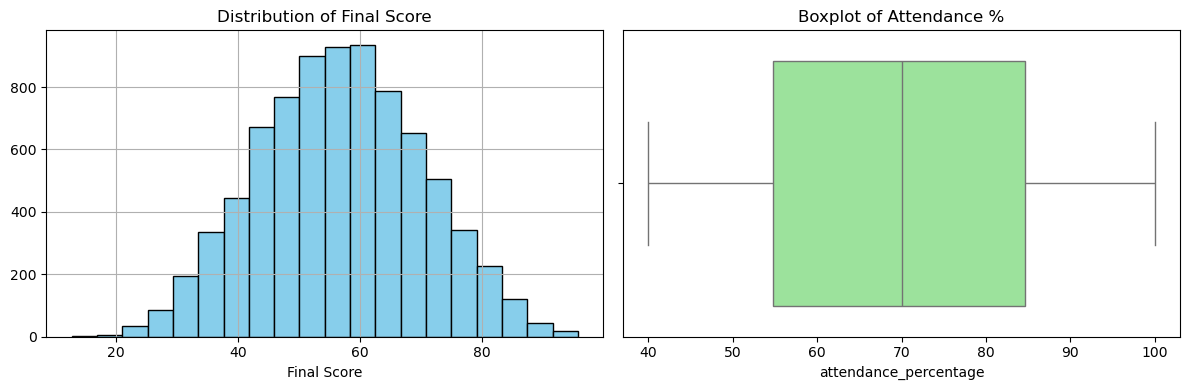

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['final_score'].hist(bins=20, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Final Score')
axes[0].set_xlabel('Final Score')

sns.boxplot(x=df['attendance_percentage'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot of Attendance %')

plt.tight_layout()
plt.show()


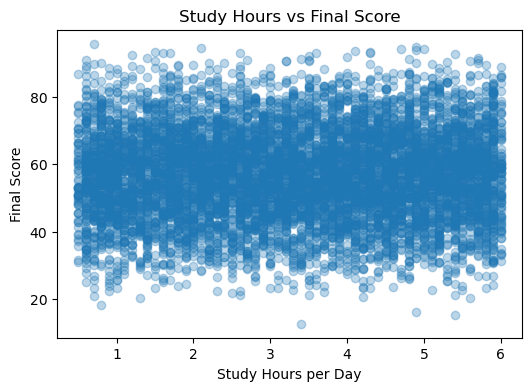

In [16]:
plt.figure(figsize=(6, 4))
plt.scatter(df['study_hours_per_day'], df['final_score'], alpha=0.3)
plt.xlabel('Study Hours per Day')
plt.ylabel('Final Score')
plt.title('Study Hours vs Final Score')
plt.show()


## 10. Visualize Categorical Data

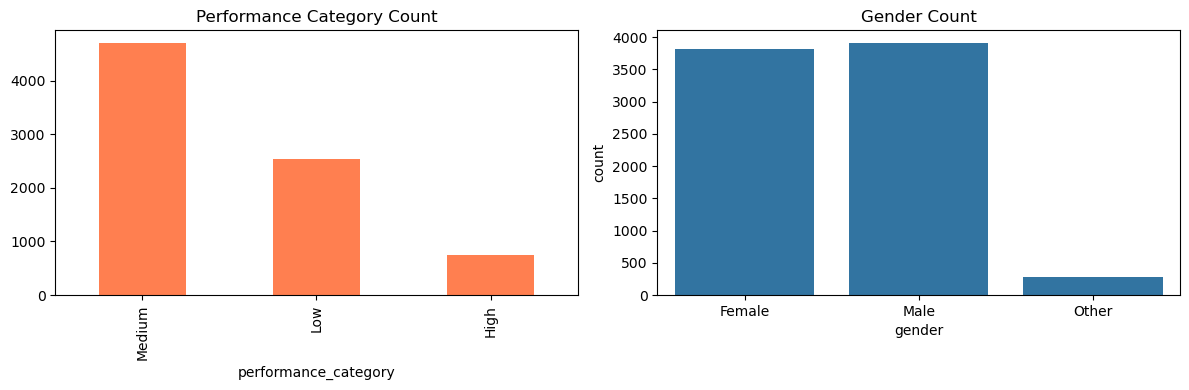

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['performance_category'].value_counts().plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Performance Category Count')

sns.countplot(x='gender', data=df, ax=axes[1])
axes[1].set_title('Gender Count')

plt.tight_layout()
plt.show()


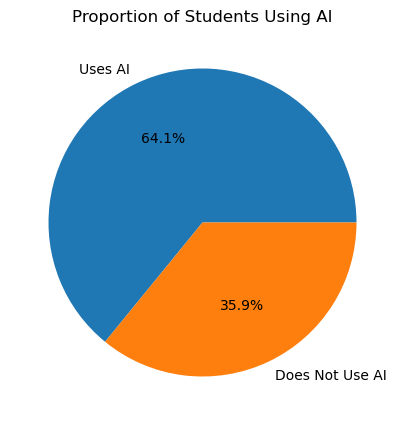

In [18]:
df['uses_ai'].value_counts().plot(
    kind='pie', labels=['Uses AI', 'Does Not Use AI'], autopct='%1.1f%%', figsize=(5, 5)
)
plt.ylabel('')
plt.title('Proportion of Students Using AI')
plt.show()


## 11. Encode Categorical Columns (for Machine Learning)

Our target column for the Student Learner Type prediction is likely
**performance_category** (Low / Medium / High). Machine learning models need numbers,
so we convert text categories into numeric form.

- **Label Encoding** for the target column (performance_category), since it has a
  natural order (Low < Medium < High).
- **One-Hot Encoding** for the other categorical columns without a natural order
  (gender, grade_level, ai_tools_used, ai_usage_purpose).

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['performance_category_encoded'] = le.fit_transform(df['performance_category'])

# Show which number represents which category
dict(zip(le.classes_, le.transform(le.classes_)))


{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

In [20]:
df = pd.get_dummies(
    df,
    columns=['gender', 'grade_level', 'ai_tools_used', 'ai_usage_purpose'],
    drop_first=True
)

df.head()


,student_id,age,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_dependency_score,ai_generated_content_percentage,ai_prompts_per_week,ai_ethics_score,last_exam_score,assignment_scores_avg,attendance_percentage,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category,performance_category_encoded,gender_Male,gender_Other,grade_level_11th,grade_level_12th,grade_level_1st Year,grade_level_2nd Year,grade_level_3rd Year,ai_tools_used_ChatGPT+Gemini,ai_tools_used_Claude,ai_tools_used_Copilot,ai_tools_used_Gemini,ai_tools_used_Not Specified,ai_usage_purpose_Doubt Solving,ai_usage_purpose_Exam Prep,ai_usage_purpose_Homework,ai_usage_purpose_Not Specified,ai_usage_purpose_Notes
0,1,20,2.5,1,170,10,29,56,5,29,40.9,98.8,4,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low,1,False,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False
1,2,17,3.4,1,123,4,14,65,1,60,87.2,89.3,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium,2,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True
2,3,24,0.8,0,35,8,82,8,5,98,77.1,50.8,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium,2,True,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False
3,4,21,4.4,0,45,3,74,106,10,67,86.4,52.1,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium,2,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True
4,5,18,3.5,1,21,2,83,7,10,40,69.4,40.7,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low,1,False,True,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False


## 12. Scale Numeric Columns (for Machine Learning)

Columns like `age` and `final_score` are on very different scales.
We use `MinMaxScaler` to bring the important numeric columns into a 0–1 range.

In [21]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

num_cols = [
    'age', 'study_hours_per_day', 'ai_usage_time_minutes', 'ai_dependency_score',
    'ai_generated_content_percentage', 'ai_prompts_per_week', 'ai_ethics_score',
    'last_exam_score', 'assignment_scores_avg', 'attendance_percentage',
    'concept_understanding_score', 'study_consistency_index', 'improvement_rate',
    'sleep_hours', 'social_media_hours', 'tutoring_hours', 'class_participation_score',
    'final_score'
]

df[num_cols] = scaler.fit_transform(df[num_cols])
df[num_cols].head()


,age,study_hours_per_day,ai_usage_time_minutes,ai_dependency_score,ai_generated_content_percentage,ai_prompts_per_week,ai_ethics_score,last_exam_score,assignment_scores_avg,attendance_percentage,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score
0,0.6,0.363636,0.949721,1.000000,0.29,0.470588,0.444444,0.113924,0.155714,0.980000,0.333333,0.888889,0.468333,0.64,0.250000,0.92,0.555556,0.290012
1,0.3,0.527273,0.687151,0.333333,0.14,0.546218,0.000000,0.506329,0.817143,0.821667,0.777778,0.833333,0.563333,0.72,0.850000,0.54,0.555556,0.635379
2,1.0,0.054545,0.195531,0.777778,0.82,0.067227,0.444444,0.987342,0.672857,0.180000,0.666667,0.122222,0.985000,0.34,0.033333,0.80,0.222222,0.645006
3,0.7,0.709091,0.251397,0.222222,0.74,0.890756,1.000000,0.594937,0.805714,0.201667,0.444444,0.633333,0.753333,0.84,0.700000,0.58,0.111111,0.683514
4,0.4,0.545455,0.117318,0.111111,0.83,0.058824,1.000000,0.253165,0.562857,0.011667,0.444444,0.488889,0.378333,0.94,0.033333,0.58,0.111111,0.445247


## 13. Final Check Before Using the Data

In [22]:
print("Final shape:", df.shape)
print("Any missing values left?:", df.isnull().sum().sum())
print("Any duplicate rows left?:", df.duplicated().sum())
df.head()


Final shape: (8000, 40)
Any missing values left?: 0
Any duplicate rows left?: 0


,student_id,age,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_dependency_score,ai_generated_content_percentage,ai_prompts_per_week,ai_ethics_score,last_exam_score,assignment_scores_avg,attendance_percentage,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category,performance_category_encoded,gender_Male,gender_Other,grade_level_11th,grade_level_12th,grade_level_1st Year,grade_level_2nd Year,grade_level_3rd Year,ai_tools_used_ChatGPT+Gemini,ai_tools_used_Claude,ai_tools_used_Copilot,ai_tools_used_Gemini,ai_tools_used_Not Specified,ai_usage_purpose_Doubt Solving,ai_usage_purpose_Exam Prep,ai_usage_purpose_Homework,ai_usage_purpose_Not Specified,ai_usage_purpose_Notes
0,1,0.6,0.363636,1,0.949721,1.000000,0.29,0.470588,0.444444,0.113924,0.155714,0.980000,0.333333,0.888889,0.468333,0.64,0.250000,0.92,0.555556,0.290012,0,Low,1,False,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False
1,2,0.3,0.527273,1,0.687151,0.333333,0.14,0.546218,0.000000,0.506329,0.817143,0.821667,0.777778,0.833333,0.563333,0.72,0.850000,0.54,0.555556,0.635379,1,Medium,2,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True
2,3,1.0,0.054545,0,0.195531,0.777778,0.82,0.067227,0.444444,0.987342,0.672857,0.180000,0.666667,0.122222,0.985000,0.34,0.033333,0.80,0.222222,0.645006,1,Medium,2,True,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False
3,4,0.7,0.709091,0,0.251397,0.222222,0.74,0.890756,1.000000,0.594937,0.805714,0.201667,0.444444,0.633333,0.753333,0.84,0.700000,0.58,0.111111,0.683514,1,Medium,2,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True
4,5,0.4,0.545455,1,0.117318,0.111111,0.83,0.058824,1.000000,0.253165,0.562857,0.011667,0.444444,0.488889,0.378333,0.94,0.033333,0.58,0.111111,0.445247,1,Low,1,False,True,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False


## 14. Save the Cleaned Dataset

In [23]:
df.to_csv('ai_impact_student_performance_dataset_cleaned.csv', index=False)
print("Cleaned dataset saved!")


Cleaned dataset saved!
